# **Clasificar a los Pacientes en Grupos Diagnósticos según los Criterios de la OMS para Comparar sus Parámetros Seminales**

## **Librerías Importadas**

In [9]:
import pandas as pd
import numpy as np
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import itertools

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from scipy.stats import binomtest, chi2, chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
from IPython.display import display

In [10]:
pd.options.display.float_format = '{:,.2f}'.format

## **Lectura de Datos**

In [11]:
df = pd.read_excel('datos.xlsx')

## **Delimitación Temporal de la Muestra**

Los registros disponibles abarcan desde 2017 hasta marzo de 2026; sin embargo, al contar únicamente con el primer trimestre de 2026, se opta por filtrar este año para mantener la consistencia del análisis, quedándonos con el período 2017–2025.

In [12]:
df = df[df['año'] != 26]
df = df.reset_index(drop=True)

## **Funciones**

### **Análisis de Asociación entre Año de Estudio y Diagnósticos de Espermograma**

La función `chi_cuadrado_diagnosticos` implementa un sistema completo de análisis de la distribución de diagnósticos de espermograma según el año de estudio. El proceso comienza asignando a cada paciente uno o más diagnósticos específicos a partir de variables binarias en el DataFrame, calculando las frecuencias globales de cada diagnóstico. Posteriormente, se aplica una prueba de chi-cuadrado de bondad de ajuste bajo el supuesto de distribución uniforme para evaluar si las proporciones de diagnósticos difieren significativamente entre sí; en caso de resultar significativa y existir más de dos categorías, se realizan pruebas post-hoc mediante el test binomial con corrección de Bonferroni para identificar qué pares de diagnósticos presentan diferencias significativas. Seguidamente, se construye una tabla de contingencia entre los años de estudio y los diagnósticos, filtrando automáticamente aquellos años sin pacientes o diagnósticos sin casos, y se aplica la prueba de chi-cuadrado de independencia, verificando los supuestos de Cochran. Si estos se cumplen, se utiliza el chi-cuadrado estándar; en caso contrario, se delega en `seleccionar_prueba_alternativa`, que selecciona automáticamente entre la prueba exacta de Fisher (para tablas 2×2), simulación de Monte Carlo con marginales fijos (cuando hay valores esperados menores a 5 pero todos superan 1) o agrupación de categorías con baja frecuencia (cuando hay valores esperados inferiores a 1), garantizando así la validez de las inferencias. Cuando se detecta una asociación significativa entre año y diagnósticos y se ha utilizado chi-cuadrado estándar, se ejecutan pruebas post-hoc mediante comparaciones por pares de filas para cada columna con la prueba exacta de Fisher y corrección de Bonferroni, seguido del análisis de residuos estandarizados y ajustados de Haberman, que identifica las celdas con desviaciones significativas (|Z| > 1.96). Finalmente, la función retorna un diccionario con los resultados del análisis de bondad de ajuste, independencia y frecuencias globales.

In [13]:
def verificar_supuestos(esperados, min_esperado=5):
    celulas_menores_min = np.sum(esperados < min_esperado)
    celulas_menores_1 = np.sum(esperados < 1)
    total_celdas = esperados.size

    cumple_esperados_min = (celulas_menores_min / total_celdas) <= 0.2
    cumple_esperados_1 = celulas_menores_1 == 0

    return {
        "cumple_supuestos": cumple_esperados_min and cumple_esperados_1,
        "cumple_80_esperados_min": cumple_esperados_min,
        "cumple_todos_esperados_1": cumple_esperados_1,
        "celulas_menores_min": celulas_menores_min,
        "celulas_menores_1": celulas_menores_1,
        "porcentaje_menores_min": (celulas_menores_min / total_celdas) * 100,
    }


def _simular_monte_carlo(tabla, n_sim=10000):
    """Calcula el p-valor por simulación de Monte Carlo (permutaciones)."""
    data_matrix = (
        tabla.to_numpy() if isinstance(tabla, pd.DataFrame) else np.asarray(tabla)
    )

    if np.any(data_matrix.sum(axis=0) == 0) or np.any(data_matrix.sum(axis=1) == 0):
        raise ValueError("La tabla contiene filas o columnas con suma cero.")

    chi2_obs, _, _, _ = chi2_contingency(data_matrix)

    filas, columnas = data_matrix.shape
    row_indices, col_indices = [], []

    for i in range(filas):
        for j in range(columnas):
            conteo = data_matrix[i, j]
            row_indices.extend([i] * conteo)
            col_indices.extend([j] * conteo)

    row_indices = np.array(row_indices)
    col_indices = np.array(col_indices)

    chi2_simulados = []
    for _ in range(n_sim):
        col_permutadas = np.random.permutation(col_indices)
        matriz_sim = np.zeros((filas, columnas), dtype=int)
        np.add.at(matriz_sim, (row_indices, col_permutadas), 1)

        if np.any(matriz_sim.sum(axis=0) == 0) or np.any(
            matriz_sim.sum(axis=1) == 0
        ):
            continue

        try:
            val_chi2 = chi2_contingency(matriz_sim)[0]
            chi2_simulados.append(val_chi2)
        except ValueError:
            continue

    if len(chi2_simulados) == 0:
        return chi2_obs, 1.0

    p_valor = float(np.mean(np.array(chi2_simulados) >= chi2_obs))
    return chi2_obs, p_valor


def seleccionar_prueba_alternativa(tabla, esperados, min_esperado=5):
    n_filas, n_cols = tabla.shape
    supuestos = verificar_supuestos(esperados, min_esperado=min_esperado)
    tabla_agrupada = None

    if n_filas == 2 and n_cols == 2:
        print("Usando prueba exacta de Fisher (tabla 2x2):")
        odds_ratio, p_valor = fisher_exact(tabla)
        return {
            "prueba": "Fisher exact test",
            "estadistico": odds_ratio,
            "p_valor": p_valor,
            "gl": None,
            "tabla_original": tabla,
            "tabla_modificada": None,
        }

    elif (
        supuestos["celulas_menores_min"] > 0
        and supuestos["celulas_menores_1"] == 0
    ):
        print("Usando simulación de Monte Carlo (totales marginales fijos):")
        estadistico, p_valor = _simular_monte_carlo(tabla)
        return {
            "prueba": "Chi-cuadrado con Monte Carlo",
            "estadistico": estadistico,
            "p_valor": p_valor,
            "gl": (n_filas - 1) * (n_cols - 1),
            "tabla_original": tabla,
            "tabla_modificada": None,
        }

    else:
        print("\nSugiriendo agrupación de categorías...")
        if not isinstance(tabla, pd.DataFrame):
            tabla = pd.DataFrame(tabla)

        frec_columnas = tabla.sum(axis=0)
        categorias_bajas = tabla.columns[frec_columnas < min_esperado].tolist()

        if len(categorias_bajas) > 0:
            print(f"Categorías con pocas observaciones: {categorias_bajas}")
            print("Creando categoría 'Otros'...")

            tabla_agrupada = tabla.copy()
            col_otros_val = tabla_agrupada[categorias_bajas].sum(axis=1)
            tabla_agrupada = tabla_agrupada.drop(columns=categorias_bajas)

            nombre_otros = "Otros"
            suffix = 1
            while nombre_otros in tabla_agrupada.columns:
                nombre_otros = f"Otros_{suffix}"
                suffix += 1

            tabla_agrupada[nombre_otros] = col_otros_val

            try:
                (
                    chi2_agrupado,
                    p_val_agrupado,
                    gl_agrupado,
                    esperados_agrupados,
                ) = chi2_contingency(tabla_agrupada)
                supuestos_agrupados = verificar_supuestos(
                    esperados_agrupados, min_esperado=min_esperado
                )

                if supuestos_agrupados["cumple_supuestos"]:
                    print("Después de agrupar, se cumplen los supuestos")
                    estadistico, p_valor = chi2_agrupado, p_val_agrupado
                    nombre_prueba = "Chi-cuadrado con categorías agrupadas"
                    gl = gl_agrupado
                else:
                    print(
                        "\nAún no se cumplen supuestos. Usando Monte Carlo en datos agrupados..."
                    )
                    estadistico, p_valor = _simular_monte_carlo(tabla_agrupada)
                    nombre_prueba = (
                        "Chi-cuadrado con Monte Carlo (datos agrupados)"
                    )
                    gl = gl_agrupado
            except Exception as e:
                print(
                    f"No se pudo agrupar adecuadamente ({e}), usando Monte Carlo en tabla original"
                )
                estadistico, p_valor = _simular_monte_carlo(tabla)
                nombre_prueba = "Chi-cuadrado con Monte Carlo"
                gl = (n_filas - 1) * (n_cols - 1)
                tabla_agrupada = None
        else:
            estadistico, p_valor, gl, _ = chi2_contingency(tabla)
            nombre_prueba = "Chi-cuadrado estándar"

    return {
        "prueba": nombre_prueba,
        "estadistico": estadistico,
        "p_valor": p_valor,
        "gl": gl,
        "tabla_original": tabla,
        "tabla_modificada": tabla_agrupada,
    }


def realizar_pruebas_posthoc_independencia(tabla, alpha=0.05):
    """
    Post-hoc para tablas de contingencia: prueba exacta de Fisher por pares de filas
    para cada columna, con corrección de Bonferroni.
    Muestra SOLO las comparaciones significativas.
    """
    filas = tabla.index.tolist()
    columnas = tabla.columns.tolist()
    p_valores, comparaciones = [], []

    for col in columnas:
        for i, j in itertools.combinations(range(len(filas)), 2):
            val_i_col = tabla.iloc[i, tabla.columns.get_loc(col)]
            val_j_col = tabla.iloc[j, tabla.columns.get_loc(col)]
            val_i_resto = tabla.iloc[i].sum() - val_i_col
            val_j_resto = tabla.iloc[j].sum() - val_j_col

            subtabla = np.array([[val_i_col, val_i_resto],
                                 [val_j_col, val_j_resto]])

            try:
                if subtabla.sum() > 0 and np.all(subtabla >= 0):
                    _, p_val = fisher_exact(subtabla)
                    p_valores.append(float(p_val))
                    comparaciones.append(
                        f"({filas[i]} vs {filas[j]}) en '{col}'"
                    )
            except Exception:
                pass

    if p_valores:
        p_ajustados = multipletests(p_valores, alpha=alpha, method="bonferroni")[
            1
        ]

        significativas = [
            (comp, p_orig, p_ajust)
            for comp, p_orig, p_ajust in zip(
                comparaciones, p_valores, p_ajustados
            )
            if p_ajust < alpha
        ]

        if significativas:
            print(f"\nComparaciones Significativas (Fisher + Bonferroni, α = {alpha}):")
            for comp, p_orig, p_ajust in significativas:
                p_orig_text = "<1e-10" if p_orig < 1e-10 else f"{p_orig:.2e}"
                p_ajust_text = "<1e-10" if p_ajust < 1e-10 else f"{p_ajust:.2e}"
                print(f"- {comp}: p-orig = {p_orig_text}, p-ajust = {p_ajust_text}")
        else:
            print(f"No hay comparaciones significativas (p ajustado < {alpha})")
    else:
        print("\nNo se pudieron realizar comparaciones por pares.")


def realizar_pruebas_posthoc_bondad(
    observados, categorias, alpha=0.05
):
    """
    Posthoc de bondad de ajuste mediante Test Binomial (Pares proporcionales).
    Muestra SOLO las comparaciones significativas.
    """
    p_valores, comparaciones = [], []

    for i, j in itertools.combinations(range(len(categorias)), 2):
        n1, n2 = observados[i], observados[j]
        total_par = n1 + n2

        if total_par > 0:
            res = binomtest(n1, n=total_par, p=0.5, alternative="two-sided")
            p_valores.append(float(res.pvalue))
            comparaciones.append(f"{categorias[i]} vs {categorias[j]}")

    if p_valores:
        _, p_ajustados, _, _ = multipletests(
            p_valores, alpha=alpha, method="bonferroni"
        )

        significativas = [
            (comp, p_orig, p_ajust)
            for comp, p_orig, p_ajust in zip(comparaciones, p_valores, p_ajustados)
            if p_ajust < alpha
        ]

        if significativas:
            print("\nComparaciones Significativas (Binomial + Bonferroni):")
            for comp, p_orig, p_ajust in significativas:
                p_orig_str = "< 1e-10" if p_orig < 1e-10 else f"{p_orig:.2e}"
                p_ajust_str = "< 1e-10" if p_ajust < 1e-10 else f"{p_ajust:.2e}"
                print(f"- {comp}: p-orig = {p_orig_str}, p-ajust = {p_ajust_str}")
        else:
            print(f"No hay comparaciones significativas (p ajustado < {alpha})")
    else:
        print("\nNo se pudieron realizar comparaciones por pares.")


def analizar_residuos(tabla, esperados):
    """Analiza los residuos estandarizados (Pearson) y ajustados de Haberman.
    Muestra los hallazgos significativos después de la tabla de residuos ajustados."""
    df_esperados = pd.DataFrame(
        esperados, index=tabla.index, columns=tabla.columns
    )
    residuos = (tabla - df_esperados) / np.sqrt(df_esperados)

    print("Residuos Estandarizados (Pearson)")
    display(residuos)

    n = tabla.values.sum()
    residuos_ajustados = pd.DataFrame(
        0.0, index=tabla.index, columns=tabla.columns
    )

    for i in range(tabla.shape[0]):
        for j in range(tabla.shape[1]):
            o_ij = tabla.iloc[i, j]
            e_ij = df_esperados.iloc[i, j]
            r_i = tabla.iloc[i].sum()
            c_j = tabla.iloc[:, j].sum()

            se = np.sqrt(e_ij * (1 - r_i / n) * (1 - c_j / n))
            if se > 0:
                residuos_ajustados.iloc[i, j] = (o_ij - e_ij) / se

    print("\nResiduos Ajustados de Haberman")
    print("Significativos (p < 0.05) si |Z| > 1.96:")
    display(residuos_ajustados)

    print("\nHallazgos Significativos en Residuos Ajustados")
    
    hallazgos_significativos = []
    for i in range(residuos_ajustados.shape[0]):
        for j in range(residuos_ajustados.shape[1]):
            valor = residuos_ajustados.iloc[i, j]
            if abs(valor) > 1.96:
                fila = residuos_ajustados.index[i]
                columna = residuos_ajustados.columns[j]
                obs = tabla.loc[fila, columna]
                esp = df_esperados.loc[fila, columna]
                direccion = "mayor" if valor > 0 else "menor"
                
                hallazgos_significativos.append({
                    "fila": fila,
                    "columna": columna,
                    "residuo": valor,
                    "observado": obs,
                    "esperado": esp,
                    "direccion": direccion
                })

    if hallazgos_significativos:
        print(f"Celdas con |residuo ajustado| > 1.96 ({len(hallazgos_significativos)} hallazgos):\n")
        for h in hallazgos_significativos:
            print(f"{h['fila']} × {h['columna']}")
            print(f"Residuo ajustado (Z) = {h['residuo']:.2f}")
            print(f"Frecuencia observada = {h['observado']}")
            print(f"Frecuencia esperada = {h['esperado']:.2f}")
            print(f"La frecuencia observada es significativamente {h['direccion']} a la esperada\n")
    else:
        print("\nNo se encontraron residuos ajustados significativos (|Z| ≤ 1.96 en todas las celdas)")
    

    return {
        "residuos_estandarizados": residuos,
        "residuos_ajustados": residuos_ajustados,
        "hallazgos_significativos": hallazgos_significativos
    }


def chi_cuadrado_diagnosticos(df, diagnosticos, alpha=0.05):
    """Analiza la distribución de diagnósticos vs años."""
    frec_total = {diag: df[diag].sum() for diag in diagnosticos}
    total_pacientes = len(df)

    df_frec_total = (
        pd.DataFrame(
            {
                "Diagnóstico": list(frec_total.keys()),
                "Frecuencia": list(frec_total.values()),
                "Porcentaje": [
                    f / total_pacientes * 100 for f in frec_total.values()
                ],
            }
        )
        .sort_values("Frecuencia", ascending=False)
        .reset_index(drop=True)
    )

    print("Tabla de Frecuencias de Diagnósticos")
    display(df_frec_total)
    print(f"Total pacientes: {total_pacientes}")

    print("\nPrueba de Bondad de Ajuste - Distribución Global de Diagnósticos")

    observados = np.array(list(frec_total.values()))
    n_categorias = len(diagnosticos)
    esperados_teoricos = np.full(n_categorias, total_pacientes / n_categorias)
    chi2_bondad = np.sum(
        ((observados - esperados_teoricos) ** 2) / esperados_teoricos
    )
    gl_bondad = n_categorias - 1

    p_valor_bondad = float(chi2.sf(chi2_bondad, df=gl_bondad))

    print("Prueba de chi-cuadrado de bondad de ajuste:")
    print(f"- Chi² = {chi2_bondad:.2f}")
    print(f"- Grados de libertad = {gl_bondad}")
    print(
        f"- p-value = {'< 1e-10' if p_valor_bondad < 1e-10 else f'{p_valor_bondad:.2e}'}"
    )

    if p_valor_bondad < alpha:
        print("- Las proporciones de diagnósticos no son uniformes")
        if n_categorias > 2:
            realizar_pruebas_posthoc_bondad(
                observados, diagnosticos, alpha
            )
    else:
        print(f"- Resultado no significativo (p >= {alpha})")

    tabla_contingencia = pd.DataFrame(index=sorted(df["año"].unique()))
    for diag in diagnosticos:
        tabla_contingencia[diag] = df.groupby("año")[diag].sum()

    tabla_contingencia = tabla_contingencia.fillna(0).astype(int)

    tabla_contingencia = tabla_contingencia.loc[tabla_contingencia.sum(axis=1) > 0]
    tabla_contingencia = tabla_contingencia.loc[:, tabla_contingencia.sum(axis=0) > 0]

    if tabla_contingencia.empty or tabla_contingencia.shape[0] < 2 or tabla_contingencia.shape[1] < 2:
        print("\nError: La tabla de contingencia no tiene suficientes filas/columnas válidas.")
        return {
            "bondad_ajuste": {
                "chi2": chi2_bondad,
                "gl": gl_bondad,
                "p_valor": p_valor_bondad,
                "posthoc": p_valor_bondad < alpha and n_categorias > 2,
            },
            "independencia": None,
            "frecuencias_globales": df_frec_total,
        }

    print("\n\nTabla de Contingencia: Año vs Diagnósticos")
    display(tabla_contingencia)
    print(
        f"\n{tabla_contingencia.shape[0]} años × {tabla_contingencia.shape[1]} diagnósticos"
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        chi2_val, p, gl, esperados = chi2_contingency(tabla_contingencia)

    supuestos = verificar_supuestos(esperados)
    print("\nPrueba de Independencia: Año vs Diagnósticos")

    if supuestos["cumple_supuestos"]:
        print(f"- Chi² = {chi2_val:.2f}")
        print(f"- Grados de libertad = {gl}")
        print(f"- p-value = {'< 1e-10' if p < 1e-10 else f'{p:.2e}'}")
        prueba_usada = "Chi-cuadrado estándar"
        p_final = p
        tabla_usada = tabla_contingencia
        esperados_usados = esperados
    else:
        print("No se cumplen todos los supuestos de chi-cuadrado")
        print(
            f"   Celdas con esperados < 5: {supuestos['celulas_menores_min']} ({supuestos['porcentaje_menores_min']:.2f}%)"
        )
        print(
            f"   Celdas con esperados < 1: {supuestos['celulas_menores_1']}"
        )

        resultado_alt = seleccionar_prueba_alternativa(
            tabla_contingencia, esperados
        )
        prueba_usada = resultado_alt["prueba"]
        estadistico_final = resultado_alt["estadistico"]
        p_final = resultado_alt["p_valor"]
        gl_final = resultado_alt.get("gl", "N/A")
        tabla_usada = (
            resultado_alt["tabla_modificada"]
            if resultado_alt["tabla_modificada"] is not None
            else tabla_contingencia
        )

        _, _, _, esperados_usados = chi2_contingency(tabla_usada)

        print(f"\n✓ Prueba usada: {prueba_usada}")
        print(f"  - Estadístico = {estadistico_final:.2f}")
        print(f"  - Grados de libertad = {gl_final}")
        print(
            f"  - p-value = {'< 1e-10' if p_final < 1e-10 else f'{p_final:.2e}'}"
        )

    if p_final < alpha:
        print("- Existe asociación entre el año y los diagnósticos")

        if (
            tabla_contingencia.shape[0] > 2 or tabla_contingencia.shape[1] > 2
        ) and prueba_usada == "Chi-cuadrado estándar":
            print("\nAnálisis posthoc por diagnóstico")
            realizar_pruebas_posthoc_independencia(tabla_contingencia, alpha)

        print("\n\nAnálisis de residuos:")
        analizar_residuos(tabla_usada, esperados_usados)
    else:
        print(f"- Resultado no significativo (p >= {alpha})")

    return {
        "bondad_ajuste": {
            "chi2": chi2_bondad,
            "gl": gl_bondad,
            "p_valor": p_valor_bondad,
            "posthoc": p_valor_bondad < alpha and n_categorias > 2,
        },
        "independencia": {
            "prueba_usada": prueba_usada,
            "p_valor": p_final,
            "tabla_contingencia": tabla_contingencia,
            "tabla_usada": tabla_usada,
        },
        "frecuencias_globales": df_frec_total,
    }

## **Clasificación de Pacientes según Diagnósticos Específicos de Espermograma**

Con el objetivo de categorizar a los pacientes según alteraciones específicas de la calidad seminal, se aplica un sistema de clasificación basado en los criterios establecidos por la Organización Mundial de la Salud (OMS). Para cada paciente, se evalúa la presencia de los siguientes diagnósticos: Azoospermia (ausencia de espermatozoides), Hipospermia (volumen < 1.4 ml), Oligozoospermia (concentración < 16 millones/ml), Astenozoospermia (motilidad progresiva < 30%), Necrozoospermia (viabilidad < 54%), Teratozoospermia (morfología normal < 4%) y Normozoospermia (todos los parámetros dentro de los rangos normales). Esta clasificación permite identificar la prevalencia de cada alteración de forma independiente, facilitando el análisis de la frecuencia de cada diagnóstico en la población estudiada.

In [14]:
condiciones = [

    # Azoospermia
    df['espermatozoides_por_eyaculado'] == 0,

    # Hipospermia
    df['volumen_ml'] < 1.4,

    # Oligozoospermia
    (
        df['concentracion_por_ml'] < 16000000
    ),

    # Astenozoospermia
    df['motilidad_progresiva_pct'] < 30,

    # Necrozoospermia 
    df['test_eosina_pct'] < 54,

    # Teratozoospermia
    df['espermatozoides_normales_pct'] < 4,

    # Normozoospermia
    (
        (df['volumen_ml'] >= 1.4) &
        (df['concentracion_por_ml'] >= 16000000) &
        (df['espermatozoides_por_eyaculado'] >= 39000000) &
        (df['motilidad_total_pct'] >= 42) &
        (df['motilidad_progresiva_pct'] >= 30) &
        (df['test_eosina_pct'] >= 54) &
        (df['espermatozoides_normales_pct'] >= 4) &
        (df['ph'] >= 7.2)
    )
]

nombres_diagnosticos = [
    'Azoospermia',
    'Hipospermia', 
    'Oligozoospermia',
    'Astenozoospermia',
    'Necrozoospermia',
    'Teratozoospermia',
    'Normozoospermia'
]

for i, nombre in enumerate(nombres_diagnosticos):
    df[nombre] = condiciones[i].astype(int)

datasets_diagnosticos = {}

for nombre in nombres_diagnosticos:
    datasets_diagnosticos[nombre] = df[df[nombre] == 1].copy()

df_azoospermia = datasets_diagnosticos['Azoospermia']
df_hipospermia = datasets_diagnosticos['Hipospermia']
df_oligozoospermia = datasets_diagnosticos['Oligozoospermia']
df_astenozoospermia = datasets_diagnosticos['Astenozoospermia']
df_necrozoospermia = datasets_diagnosticos['Necrozoospermia']
df_teratozoospermia = datasets_diagnosticos['Teratozoospermia']
df_normozoospermia = datasets_diagnosticos['Normozoospermia']

## **Evaluación de la Asociación entre Año de Estudio y Diagnósticos de Espermograma**

Para evaluar la distribución de los diagnósticos de espermograma según el año de estudio y su evolución temporal, se aplica la función de análisis que implementa pruebas de chi-cuadrado de bondad de ajuste e independencia, con verificación de supuestos y selección automática de pruebas alternativas robustas. Los resultados permitirán determinar si existe una distribución uniforme de los diagnósticos en la muestra y si el año de estudio se asocia significativamente con la presencia de cada alteración seminal.

In [15]:
resultado = chi_cuadrado_diagnosticos(df, nombres_diagnosticos) 

Tabla de Frecuencias de Diagnósticos


,Diagnóstico,Frecuencia,Porcentaje
0,Teratozoospermia,1788,52.79
1,Astenozoospermia,1003,29.61
2,Oligozoospermia,963,28.43
3,Normozoospermia,801,23.65
4,Necrozoospermia,428,12.64
5,Hipospermia,372,10.98
6,Azoospermia,168,4.96


Total pacientes: 3387

Prueba de Bondad de Ajuste - Distribución Global de Diagnósticos
Prueba de chi-cuadrado de bondad de ajuste:
- Chi² = 4992.91
- Grados de libertad = 6
- p-value = < 1e-10
- Las proporciones de diagnósticos no son uniformes

Comparaciones Significativas (Binomial + Bonferroni):
- Azoospermia vs Hipospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Azoospermia vs Oligozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Azoospermia vs Astenozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Azoospermia vs Necrozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Azoospermia vs Teratozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Azoospermia vs Normozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Hipospermia vs Oligozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Hipospermia vs Astenozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Hipospermia vs Teratozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10
- Hipospermia vs Normozoospermia: p-orig = < 1e-10, p-ajust = < 1e-10

,Azoospermia,Hipospermia,Oligozoospermia,Astenozoospermia,Necrozoospermia,Teratozoospermia,Normozoospermia
17,21,54,117,106,49,267,72
18,18,54,128,140,53,250,114
19,32,31,141,143,63,233,123
20,19,35,101,90,44,161,85
21,15,46,91,119,49,179,102
22,21,43,103,97,38,171,94
23,14,46,105,106,32,159,81
24,12,31,80,92,42,159,75
25,16,32,97,110,58,209,55



9 años × 7 diagnósticos

Prueba de Independencia: Año vs Diagnósticos
- Chi² = 82.91
- Grados de libertad = 48
- p-value = 1.31e-03
- Existe asociación entre el año y los diagnósticos

Análisis posthoc por diagnóstico
No hay comparaciones significativas (p ajustado < 0.05)


Análisis de residuos:
Residuos Estandarizados (Pearson)


,Azoospermia,Hipospermia,Oligozoospermia,Astenozoospermia,Necrozoospermia,Teratozoospermia,Normozoospermia
17,0.03,1.15,-0.24,-1.66,-0.57,3.01,-2.76
18,-1.05,0.42,-0.35,0.22,-0.74,0.31,0.40
19,1.80,-2.87,0.64,0.33,0.47,-0.95,1.13
20,0.68,-0.17,0.80,-0.73,0.39,-0.93,0.84
21,-0.77,0.87,-1.35,0.94,0.36,-1.12,1.59
22,0.90,0.78,0.42,-0.59,-0.90,-0.93,1.30
23,-0.62,1.56,1.06,0.74,-1.55,-1.27,0.25
24,-0.76,-0.36,-0.61,0.30,0.64,0.00,0.45
25,-0.37,-1.10,-0.36,0.51,1.99,1.62,-3.14



Residuos Ajustados de Haberman
Significativos (p < 0.05) si |Z| > 1.96:


,Azoospermia,Hipospermia,Oligozoospermia,Astenozoospermia,Necrozoospermia,Teratozoospermia,Normozoospermia
17,0.03,1.27,-0.28,-1.97,-0.63,3.92,-3.19
18,-1.15,0.47,-0.41,0.26,-0.83,0.41,0.47
19,1.97,-3.20,0.76,0.39,0.53,-1.25,1.32
20,0.72,-0.19,0.93,-0.84,0.43,-1.19,0.96
21,-0.83,0.95,-1.57,1.10,0.39,-1.44,1.82
22,0.97,0.85,0.48,-0.69,-0.98,-1.19,1.48
23,-0.66,1.70,1.23,0.87,-1.70,-1.62,0.29
24,-0.81,-0.39,-0.70,0.35,0.70,0.00,0.51
25,-0.40,-1.20,-0.42,0.60,2.19,2.09,-3.58



Hallazgos Significativos en Residuos Ajustados
Celdas con |residuo ajustado| > 1.96 (8 hallazgos):

17 × Astenozoospermia
Residuo ajustado (Z) = -1.97
Frecuencia observada = 106
Frecuencia esperada = 124.58
La frecuencia observada es significativamente menor a la esperada

17 × Teratozoospermia
Residuo ajustado (Z) = 3.92
Frecuencia observada = 267
Frecuencia esperada = 222.08
La frecuencia observada es significativamente mayor a la esperada

17 × Normozoospermia
Residuo ajustado (Z) = -3.19
Frecuencia observada = 72
Frecuencia esperada = 99.49
La frecuencia observada es significativamente menor a la esperada

19 × Azoospermia
Residuo ajustado (Z) = 1.97
Frecuencia observada = 32
Frecuencia esperada = 23.30
La frecuencia observada es significativamente mayor a la esperada

19 × Hipospermia
Residuo ajustado (Z) = -3.20
Frecuencia observada = 31
Frecuencia esperada = 51.59
La frecuencia observada es significativamente menor a la esperada

25 × Necrozoospermia
Residuo ajustado (Z) = 2.19

**Resumen General**

El análisis de la distribución de diagnósticos de espermograma revela que las proporciones de diagnósticos no son uniformes (p < 1e-10), con Teratozoospermia como el diagnóstico más frecuente (52.79% de los pacientes) y Azoospermia como el menos frecuente (4.96%). La prueba de independencia muestra una asociación significativa entre el año de estudio y los diagnósticos (p = 1.31e-03). El análisis de residuos ajustados identifica 8 asociaciones significativas, destacando un aumento de Teratozoospermia y disminución de Normozoospermia en 2017, un aumento de Azoospermia y disminución de Hipospermia en 2019, y un aumento de Necrozoospermia y Teratozoospermia con disminución de Normozoospermia en 2025.

**Distribución Global de Diagnósticos**

- Teratozoospermia es el diagnóstico más frecuente, afectando a más de la mitad de los pacientes (52.79%)
- Astenozoospermia y Oligozoospermia afectan a aproximadamente 1 de cada 3 pacientes
- Normozoospermia solo se presenta en el 23.65% de los pacientes
- Azoospermia es el diagnóstico menos frecuente (4.96%)

**Prueba de Bondad de Ajuste**

- La distribución de diagnósticos es muy diferente a una distribución uniforme
- Teratozoospermia está muy sobrerrepresentada (52.79% vs 14.3% esperado)
- Azoospermia está muy subrrepresentada (4.96% vs 14.3% esperado)

**Comparaciones Post-hoc Significativas (p < 0.05)**

- La prevalencia de cada diagnóstico es significativamente diferente de los demás
- Teratozoospermia es el diagnóstico más frecuente y difiere de todos los demás
- Azoospermia es el menos frecuente y difiere de todos los demás

**Asociación entre Año y Diagnósticos**

- Existe una asociación significativa entre el año de estudio y los diagnósticos
- La distribución de diagnósticos ha variado a lo largo del tiempo

**Año 2017**

| Diagnóstico | Residuo | Frecuencia Observada | Frecuencia Esperada | Interpretación |
|-------------|---------|---------------------|---------------------|----------------|
| Teratozoospermia | +3.92 | 267 | 222.1 | Significativamente mayor a lo esperado |
| Normozoospermia | -3.19 | 72 | 99.5 | Significativamente menor a lo esperado |
| Astenozoospermia | -1.97 | 106 | 124.6 | Cercano al límite (p=0.05) |

**Año 2019**

| Diagnóstico | Residuo | Frecuencia Observada | Frecuencia Esperada | Interpretación |
|-------------|---------|---------------------|---------------------|----------------|
| Azoospermia | +1.97 | 32 | 23.3 | Significativamente mayor a lo esperado |
| Hipospermia | -3.20 | 31 | 51.6 | Significativamente menor a lo esperado |


**Año 2025**

| Diagnóstico | Residuo | Frecuencia Observada | Frecuencia Esperada | Interpretación |
|-------------|---------|---------------------|---------------------|----------------|
| Necrozoospermia | +2.19 | 58 | 44.7 | Significativamente mayor a lo esperado |
| Teratozoospermia | +2.09 | 209 | 186.8 | Significativamente mayor a lo esperado |
| Normozoospermia | -3.58 | 55 | 83.7 | Significativamente menor a lo esperado |


**Resumen de Hallazgos por Año**

| Año | Diagnóstico con Aumento | Diagnóstico con Disminución | Interpretación |
|-----|------------------------|----------------------------|----------------|
| 2017 | Teratozoospermia (Z=3.92) | Normozoospermia (Z=-3.19) | Alta alteración morfológica, baja normalidad |
| 2019 | Azoospermia (Z=1.97) | Hipospermia (Z=-3.20) | Aumento de azoospermia, disminución de hipospermia |
| 2025 | Necrozoospermia (Z=2.19) Teratozoospermia (Z=2.09) | Normozoospermia (Z=-3.58) | Aumento de alteraciones, disminución de normalidad |

**Conclusión Final**

El análisis de diagnósticos de espermograma muestra que Teratozoospermia es el diagnóstico más frecuente, afectando al 52.79% de los pacientes, mientras que Azoospermia es el menos frecuente (4.96%). Existe una asociación significativa entre el año de estudio y los diagnósticos (p = 1.31e-03). El análisis de residuos identifica 8 asociaciones significativas, destacando aumentos de Teratozoospermia y disminuciones de Normozoospermia en 2017, aumentos de Azoospermia y disminuciones de Hipospermia en 2019, y aumentos de Necrozoospermia y Teratozoospermia con disminución de Normozoospermia en 2025. La tendencia en 2025 sugiere un deterioro en la calidad seminal, con menos pacientes normales y más alteraciones.

## Visualización de la Distribución Temporal de Diagnósticos de Espermograma

Para representar gráficamente la evolución temporal de los diagnósticos de espermograma a lo largo de los años de estudio, se genera un gráfico de barras apiladas que muestra la distribución porcentual de cada diagnóstico (Azoospermia, Hipospermia, Oligozoospermia, Astenozoospermia, Necrozoospermia, Teratozoospermia y Normozoospermia) para cada año. Esta visualización permite observar de forma intuitiva los cambios en la composición diagnóstica a lo largo del tiempo, facilitando la identificación de tendencias y patrones en la prevalencia de las diferentes alteraciones seminales en la población estudiada.

Distribución de Diagnósticos según Año de Estudio


,Azoospermia,Hipospermia,Oligozoospermia,Astenozoospermia,Necrozoospermia,Teratozoospermia,Normozoospermia
año,,,,,,,
17,3.06,7.87,17.06,15.45,7.14,38.92,10.50
18,2.38,7.13,16.91,18.49,7.00,33.03,15.06
19,4.18,4.05,18.43,18.56,8.24,30.46,16.08
20,3.56,6.37,18.91,16.85,8.24,30.15,15.92
21,2.50,7.65,15.14,19.80,8.15,29.78,16.97
22,3.70,7.58,18.17,17.11,6.70,30.16,16.58
23,2.58,8.47,19.34,19.52,5.89,29.28,14.92
24,2.44,6.31,16.29,18.74,8.55,32.38,15.27
25,2.77,5.55,16.81,19.06,10.05,36.22,9.53


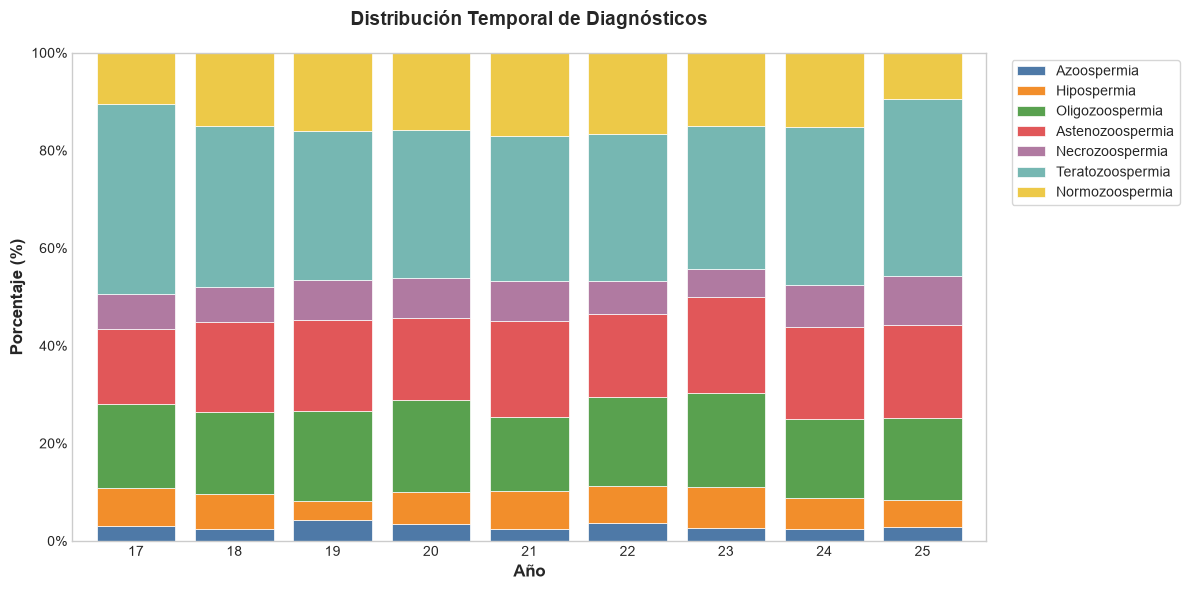

In [16]:
colors = [
    "#4E79A7",  # Azul
    "#F28E2B",  # Naranja
    "#59A14F",  # Verde
    "#E15759",  # Rojo
    "#B07AA1",  # Morado
    "#76B7B2",  # Turquesa
    "#EDC948",  # Mostaza
    "#9C755F",  # Marrón
    "#BAB0AC",  # Gris
    "#7F7F7F",  # Gris oscuro
    "#2F4B7C"   # Azul marino
]

data = {
    'Azoospermia': [21, 18, 32, 19, 15, 21, 14, 12, 16],
    'Hipospermia': [54, 54, 31, 34, 46, 43, 46, 31, 32],
    'Oligozoospermia': [117, 128, 141, 101, 91, 103, 105, 80, 97],
    'Astenozoospermia': [106, 140, 142, 90, 119, 97, 106, 92, 110],
    'Necrozoospermia': [49, 53, 63, 44, 49, 38, 32, 42, 58],
    'Teratozoospermia': [267, 250, 233, 161, 179, 171, 159, 159, 209],
    'Normozoospermia': [72, 114, 123, 85, 102, 94, 81, 75, 55]
}

df = pd.DataFrame(data, index=[17, 18, 19, 20, 21, 22, 23, 24, 25])
df.index.name = 'año'

variable = None
nombre_parametro = "Diagnósticos"

categorias = df.columns.tolist()

colores_asignados = colors[:len(categorias)]
color_map_var = dict(zip(categorias, colores_asignados))

tabla = df.div(df.sum(axis=1), axis=0) * 100

print(f'Distribución de {nombre_parametro} según Año de Estudio')
display(tabla)


plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))


tabla.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[color_map_var[col] for col in tabla.columns],
    width=0.8,
    edgecolor='white',
    linewidth=0.5
)

ax.set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Año', fontsize=12, fontweight='bold')

ax.set_title(f'Distribución Temporal de {nombre_parametro}',
             fontsize=14,
             fontweight='bold',
             pad=20)

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=10,
    title_fontsize=11,
    frameon=True,
    fancybox=True,
    shadow=False
)

ax.tick_params(axis='x', rotation=0, labelsize=10)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}%'))
ax.grid(False)

plt.tight_layout()
plt.show()